Purpose: To explore the Bhutan watershed boundary from the Bhutan NSDI System website.

Install libraries </bt>
- here on the notebook or 
- from terminal within a python virtual environment<br/>

For Notebook option <br/>
 ```
 !pip install --upgrade pip
 !pip install -r requirements.txt
 ``` 
<br/>

For terminal option <br/>
open up a new terminal for instance in a VSCode environment
```
> python -m venv bb_venv <br/>
> bb_venv\Scripts\activate.bat <br/>
(bb_venv)> python -m pip install --upgrade pip  <br/>
(bb_venv)> pip install -r requirements.txt <br/>
```
<br/>


**NOTE:First time run, you need to choose the python environment and it might install ipykernel as well**

In [1]:
!pip install --upgrade pip
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


**Import Libraries**

In [2]:
import os
import pandas as pd
import numpy as np
import yaml

import fiona
import geopandas as gpd
from shapely.geometry import Point
from shapely.wkt import dumps
import matplotlib.pyplot as plt 

import json
import re
from functools import reduce

from pyproj import CRS


needs the following libraries installed
- cfgrib
- xarray
- eccodes
- shapely 
- fiona
- geopandas
- pyproj
- rtree

- PyYaml

NOTE: for now we aren't yet using climatesense.yaml - something to think about



In [3]:
cwd = os.getcwd()
cwd


'c:\\PS\\Projects\\Omdena\\bhutan_climate_modeling\\code\\watershed'

**Set up base path for data**

In [4]:
def get_base_data_path(src="", path_suffix=""):
    config_data = None
    base_data_dir = ""
    if src == "":
        base_data_dir = f"../../data{path_suffix}"
    else:
        print("yaml - config settings not in use yet...")
        # # Load the .yaml file to load all the cofiguration settings for the app
        # # like base data path and any other common information needed all through the Climatesense app
        # with open('climatesense.yaml', 'r') as f:
        #     config_data = yaml.safe_load(f)

        # base_data_dir = base_data_dir['data_dir']['base_dir']

    return base_data_dir

# save final_output_v1 for now in the data folder itself
def save_to_file(df, folder_path="", file_path=""):
    os.makedirs(folder_path, exist_ok=True, mode=0o777)
    save_file = f"{folder_path}/{file_path}.csv"
    df.to_csv(save_file, index=False)
    

##### **Explore Bhutan 186 Watershed data**

**Set watershed data paths**

In [5]:
base_data_path = get_base_data_path()
base_data_path

'../../data'

In [6]:
watershed_boundary_data_path = get_base_data_path(path_suffix="/boundaries/186_watershed")
watershed_boundary_data_path

'../../data/boundaries/186_watershed'

**Inpect .prj file of watershed boundary, to check the CRS used, if present**

In [7]:
wb_prj_file = f"{watershed_boundary_data_path}/186 Watershed boundary.prj"

In [8]:
with open(wb_prj_file, "r") as prj_file:
    prj_text = prj_file.read()

In [9]:
# check if prj_text holds the content of 'Bhutan boundary.prj' file
crs = CRS(prj_text)
epsg = crs.to_epsg()
print(f"Name: {crs.name}")
print(f"Coordinate system: {crs.coordinate_system}")
print(f"Area of Use: {crs.area_of_use}")
print(f"EPSG Code (if available): {epsg}")

Name: WGS 84 / Pseudo-Mercator
Coordinate system: cartesian
Area of Use: None
EPSG Code (if available): 3857


**Load the previously downloaded Bhutan - (186) Watershed boundary data .shp file**

In [10]:
wb_shp_file = f"{watershed_boundary_data_path}/186 Watershed boundary.shp"

In [11]:
def load_watershed_data(shp_file="", prj_crs=None):
    gdf_orig = None
    df_gdf_watershed_wgs84 = None
    # NOTE: features are the rows from the shp file
    # Refer: https://gis.stackexchange.com/questions/448450/getting-the-number-of-features-in-shapefile-without-opening-it-using-python
    #
    # If we have arcgis account then we can use, similar to below link...
    # Refer: https://gis.stackexchange.com/questions/381120/convert-arcgis-spatially-enabled-dataframe-to-geopandas-geodataframe

    # load shp file
    with fiona.open(shp_file) as features:
        print(f"Total features in watershed boundary .shp file: {len(features)}")

        gdf_orig = gpd.GeoDataFrame.from_features(features)
        print(f"Loaded geoDataFrame shape: {gdf_orig.shape}")
        print(f"crs: {gdf_orig.crs}")
    # print(gdf_orig.head(2))

    # Set the correct CRS from the .prj file (Web Mercator)
    gdf_orig.set_crs(epsg=prj_crs, inplace=True)

    # Reproject to WGS84 (EPSG:4326)
    df_gdf_watershed_wgs84 = gdf_orig.to_crs("EPSG:4326")

    # Calculate centroids in WGS84
    centroids = df_gdf_watershed_wgs84.geometry.centroid

    # Extract longitude and latitude
    df_gdf_watershed_wgs84['longitude'] = centroids.x
    df_gdf_watershed_wgs84['latitude'] = centroids.y

    # Print the range
    print(f"Longitude range: {df_gdf_watershed_wgs84['longitude'].min()} to {df_gdf_watershed_wgs84['longitude'].max()}")
    print(f"Latitude range: {df_gdf_watershed_wgs84['latitude'].min()} to {df_gdf_watershed_wgs84['latitude'].max()}")
    # print(df_gdf_watershed_wgs84[['watershed', 'longitude', 'latitude']].head())
    return df_gdf_watershed_wgs84


In [12]:
# load watershed boundary data
gdf_watershed_wgs84 = load_watershed_data(shp_file=wb_shp_file, prj_crs=epsg)
gdf_watershed_wgs84.head(2)

Total features in watershed boundary .shp file: 186
Loaded geoDataFrame shape: (186, 7)
crs: None
Longitude range: 88.88744181061193 to 92.03911802358823
Latitude range: 26.739830166575217 to 28.149654478026033


C:\Users\Pankaja\AppData\Local\Temp\ipykernel_17512\3116127710.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df_gdf_watershed_wgs84.geometry.centroid


,geometry,f_area,ws_id,area_ha,area_ha_1,SHAPE__Len,SHAPE__Are,longitude,latitude
0,"POLYGON ((92.04047 27.25524, 92.03816 27.25527...",1.403314e+08,1,14033.1356069597,14033.135607,88962.631299,1.783218e+08,92.034245,27.328438
1,"POLYGON ((89.74885 28.1869, 89.74993 28.18672,...",1.069433e+08,2,10694.331035308,10694.331035,72762.793824,1.380322e+08,89.693993,28.133971


In [13]:
# just check the crs before visualizing to make sure it is WGS84
gdf_watershed_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

##### **Watershed stats**

In [14]:
gdf_watershed_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
gdf_watershed_wgs84.columns

Index(['geometry', 'f_area', 'ws_id', 'area_ha', 'area_ha_1', 'SHAPE__Len',
       'SHAPE__Are', 'longitude', 'latitude'],
      dtype='object')

**Get watershed shp stats and save**

In [16]:
def get_watershed_boundary_stats(gdf=None):
    # save watershed boundary stats
    watersheds = gdf['ws_id']

    # perimeter
    perimeter_kms = []
    for idx, row in gdf.iterrows():
        perimeter_meters = row.geometry.length
        # Convert the perimeter to kilometers.
        perimeter_km = perimeter_meters / 1000
        # print(f"perimeter km: {round(perimeter_km, 4)}") 
        perimeter_kms.append(perimeter_km)

    # geometry counts
    geometry_counts = gdf.geometry.count_geometries()
    total_geometries = geometry_counts.sum()
    # total_geometries
    
    # area km2
    geom = gdf.geometry.to_crs(epsg=4326)
    watershed_area_sq_km = geom.area / 10**6

    # Summary statistics
    summary = {
        "Total watersheds": len(watersheds),
        "Total area (km²)": watershed_area_sq_km.sum(),
        "Average area (km²)": watershed_area_sq_km.mean(),
        "Min area (km²)": watershed_area_sq_km.min(),
        "Max area (km²)": watershed_area_sq_km.max(),
        "Average perimeter (km)": np.mean(perimeter_kms),
        "Min perimeter (km)": np.min(perimeter_kms),
        "Max perimeter (km)": np.max(perimeter_kms),
        "Total geometries": total_geometries
    }

    df_watershed_stats = pd.json_normalize(summary)

    return df_watershed_stats

In [17]:
# Asswmble watershed boundary stats
watershed_stats = get_watershed_boundary_stats(gdf=gdf_watershed_wgs84)
watershed_stats

C:\Users\Pankaja\AppData\Local\Temp\ipykernel_17512\2953557693.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  watershed_area_sq_km = geom.area / 10**6


,Total watersheds,Total area (km²),Average area (km²),Min area (km²),Max area (km²),Average perimeter (km),Min perimeter (km),Max perimeter (km),Total geometries
0,186,0.000004,1.898425e-08,3.972219e-09,8.295818e-08,0.000862,0.000353,0.002392,186


**Calculate perimeter and geometry per watershed, before saving the details**

In [18]:
def calculate_perimeter_km(row):
    # Calculate perimeter of watershed
    perimeter_meters = row.geometry.length
    # Convert the perimeter to kilometers
    perimeter_km = perimeter_meters / 1000
    return perimeter_km

def calculate_area_sqkm(df):
    df_copy = df.copy(deep=True)
    # Calculate area sqkm of watershed
    area_km_arr = []
    for idx, row in df_copy.iterrows():
        geom = row.geometry
        watershed_area_sq_km = geom.area / 10**6
        area_km_arr.append(watershed_area_sq_km)
    df_copy['area_sqkm'] = area_km_arr
    return df_copy 

def calculate_geometries(df):
    df_copy = df.copy(deep=True)
    # Calculate number of geometries by watershed
    gcounts = []
    gc_json = json.loads(df.count_geometries().to_json())
    for idx, row in df_copy.iterrows():
        gcount = gc_json[str(idx)]
        gcounts.append(gcount)

    df_copy['geometry_count'] = gcounts
    return df_copy

def encapsulate_geom_column(df):
    df_copy = df.copy(deep=True)

    df_copy['geom'] = df_copy['geometry'].apply(dumps)
    df_copy = df_copy.drop(columns=['geometry'])
    return df_copy


In [19]:
# calculate perimeter of each watershed
ws_details = gdf_watershed_wgs84.copy(deep=True)
ws_details['perimeter_km'] = ws_details.apply(lambda r: calculate_perimeter_km(r), axis=1)

In [20]:
# calculate area sqkm of each watershed
df_ws_details_pre = calculate_area_sqkm(ws_details)

In [21]:
# calculate the geometries by watershed
# NOTE: there can be more than one geometry per watershed
df_ws_details_pre = calculate_geometries(df_ws_details_pre)
df_ws_details_pre.head(2)

,geometry,f_area,ws_id,area_ha,area_ha_1,SHAPE__Len,SHAPE__Are,longitude,latitude,perimeter_km,area_sqkm,geometry_count
0,"POLYGON ((92.04047 27.25524, 92.03816 27.25527...",1.403314e+08,1,14033.1356069597,14033.135607,88962.631299,1.783218e+08,92.034245,27.328438,0.000750,1.278395e-08,1
1,"POLYGON ((89.74885 28.1869, 89.74993 28.18672,...",1.069433e+08,2,10694.331035308,10694.331035,72762.793824,1.380322e+08,89.693993,28.133971,0.000615,9.822709e-09,1


In [22]:
df_ws_details_pre.columns

Index(['geometry', 'f_area', 'ws_id', 'area_ha', 'area_ha_1', 'SHAPE__Len',
       'SHAPE__Are', 'longitude', 'latitude', 'perimeter_km', 'area_sqkm',
       'geometry_count'],
      dtype='object')

**NOTE**
- 'geometry' column has to dropped as directly saving the geometry column to a csv representation is not possible
   (Tried wkt representation, but that also creates additional column upon saving to csv)
- 'area_ha_1' column is dropped because it is a copy of 'area_ha' column

In [23]:
# set rearrange column order
cols = ['ws_id','longitude', 'latitude', 'area_sqkm', 'perimeter_km', 'geometry_count', 'SHAPE__Len', 'SHAPE__Are']
# NOTE:
# drop 'area_ha_1' and 'geometry' columns 
df_ws_details_pre.drop(columns=['area_ha_1', 'geometry'], inplace=True)

# ******** Below is commented as it doesn't seem to work *********
# df_ws_details_pre = encapsulate_geom_column(df_ws_details_pre)
# ****************************************************************

# rearrange columns 
df_ws_details = df_ws_details_pre[cols + [c for c in df_ws_details_pre.columns if c not in cols]]

print(f"Total watershed shape rows: {df_ws_details.shape[0]}")
df_ws_details

Total watershed shape rows: 186


,ws_id,longitude,latitude,area_sqkm,perimeter_km,geometry_count,SHAPE__Len,SHAPE__Are,f_area,area_ha
0,1,92.034245,27.328438,1.278395e-08,0.000750,1,88962.631299,1.783218e+08,1.403314e+08,14033.1356069597
1,2,89.693993,28.133971,9.822709e-09,0.000615,1,72762.793824,1.380322e+08,1.069433e+08,10694.331035308
2,3,89.613690,28.076917,1.508835e-08,0.000744,1,87853.120695,2.119142e+08,1.634449e+08,16436.0007344264
3,4,89.805772,28.149654,1.907842e-08,0.000849,1,100646.751220,2.681361e+08,2.076810e+08,20768.1036079112
4,5,90.156739,28.128583,8.411641e-09,0.000521,1,62076.446669,1.181974e+08,9.158350e+07,9158.35047410094
...,...,...,...,...,...,...,...,...,...,...
181,182,90.235785,26.916367,2.028637e-08,0.000874,1,103077.140454,2.819314e+08,2.232692e+08,22327.0066383582
182,183,90.381975,26.958202,8.475830e-09,0.000583,1,68574.466350,1.178372e+08,9.247798e+07,9325.24891666983
183,184,91.449308,26.913445,2.814488e-08,0.001225,1,143491.728489,3.911354e+08,3.099220e+08,30992.2044932785
184,185,91.792128,26.885323,5.477096e-09,0.000488,1,57640.400766,7.609741e+07,6.034296e+07,6034.29619042508


In [24]:
df_ws_details.shape

(186, 10)

In [25]:
# save watershed_boundary details
watershed_stats_dir = get_base_data_path(path_suffix="/boundaries/processed")
save_wb_stats_file = "watershed_shape_stats"
save_to_file(df_ws_details, folder_path=watershed_stats_dir, file_path=save_wb_stats_file)


**Visualize (186) watershed boundary geoDataFrame**

In [26]:
def plot_watershed_boundaries(gdf=None, plt_title="", column=""):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Plot the watershed polygons (not points)
    # gdf.plot(ax=ax, column='watershed', cmap='viridis', edgecolor='black', legend=True)
    gdf.plot(ax=ax, column=column, cmap='viridis', edgecolor='black')

    # Add watershed name labels at centroid positions
    for idx, row in gdf.iterrows():
        ax.text(row['longitude'], row['latitude'], row[column],
                horizontalalignment='center', verticalalignment='center',
                fontsize=5, color='white', weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.title(plt_title, fontsize=10)

    # Set axis limits to the extent of your data
    ax.set_xlim(gdf['longitude'].min()-0.35, gdf['longitude'].max()+0.7)
    ax.set_ylim(gdf['latitude'].min()-0.35, gdf['latitude'].max()+0.85)

    plt.show()



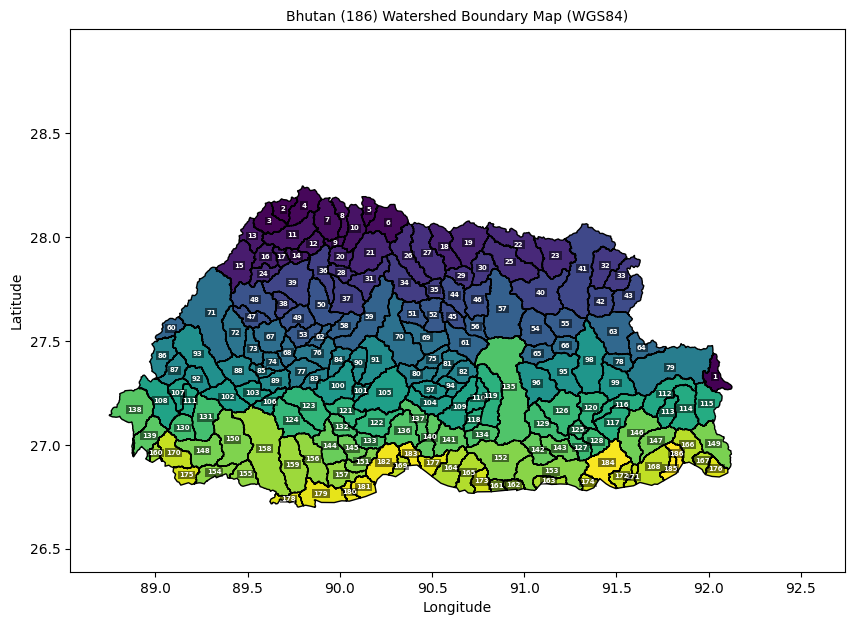

In [27]:
# plot (186) watershed-boundaries
plot_watershed_boundaries(gdf=gdf_watershed_wgs84, 
                          plt_title="Bhutan (186) Watershed Boundary Map (WGS84)",
                          column="ws_id")
